# Challenge 17

create a python script that:

1. Constructs the coefficient matrix for Euler's Method.
2. Computes the eigenvalues to check stability, use the built in functions
   - If the magnitude of any eigenvalue exceeds 1, the solution is unstable for that step size.
3. Simulates the numerical solution for different step sizes and visualizes the results.

Output: 
1. Display the step size
2. if the magnitude of the eigenvalues for that step size are < 1
    - Display "Solution is Stable"
    - else display "Solution may not be Entirely Stable ;)"
3. Plot the solution curve

h=0.01
Eigenvalues: [1.+0.01j 1.-0.01j]
Solution may not be Entirely Stable ;)


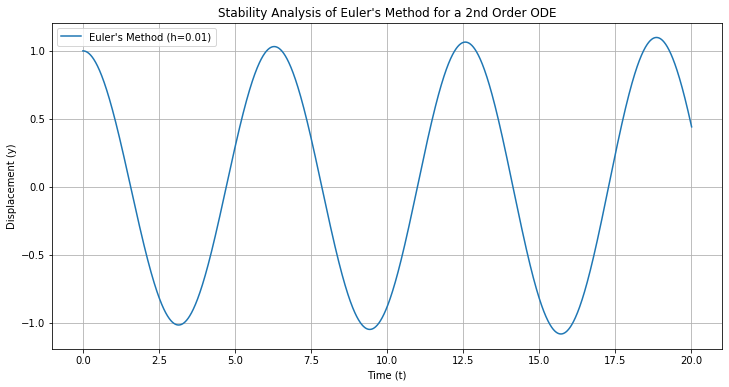

h=0.10
Eigenvalues: [1.+0.1j 1.-0.1j]
Solution may not be Entirely Stable ;)


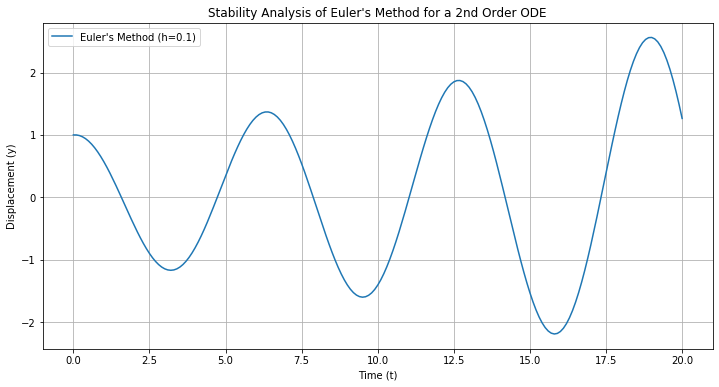

h=0.50
Eigenvalues: [1.+0.5j 1.-0.5j]
Solution may not be Entirely Stable ;)


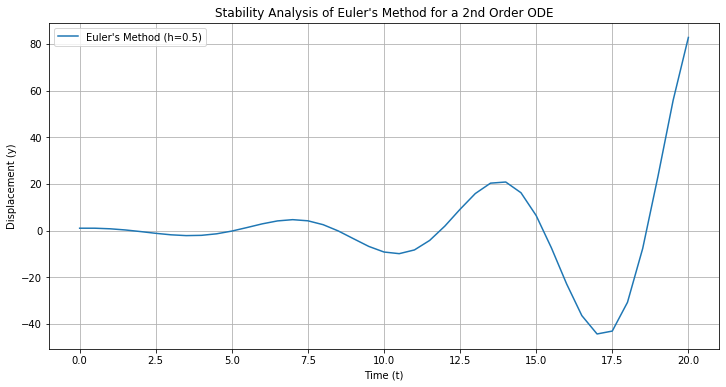

h=1.00
Eigenvalues: [1.+1.j 1.-1.j]
Solution may not be Entirely Stable ;)


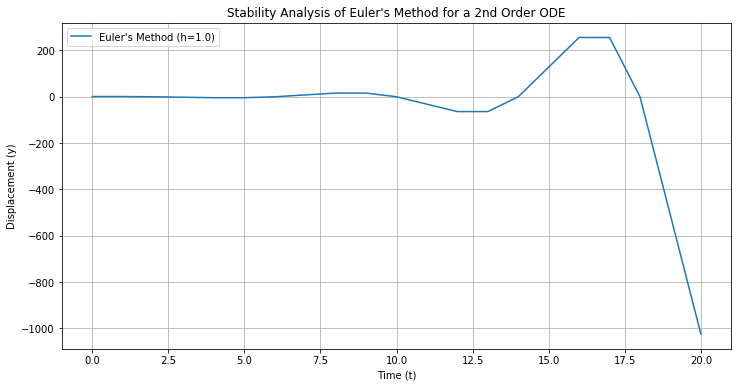

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

k = 1.0
h_values = [0.01, 0.1, 0.5, 1.0]
t_start = 0
t_end = 20
y_0 = 1.0
v_0 = 0.0

def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]    
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
    
    return t_values, y_values
          
for h in h_values:
    print(f"h={h:.2f}")
    
    # coefficient matrix
    C = np.array([[1, h], [-h*k, 1]])
    eigenvals = np.linalg.eig(C)[0]
    
    print("Eigenvalues:", eigenvals)
    if max(eigenvals) > 1:
        print("Solution may not be Entirely Stable ;)")
    else:
        print("Solution is Stable")
          
    plt.figure(figsize=(12, 6))
    
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
    
    plt.xlabel('Time (t)')
    plt.ylabel('Displacement (y)')
    plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
    plt.legend()
    plt.grid(True)
    plt.show()